# Model Diagnostics and Error Analysis

Цель: разобрать уже обученную модель из `artifacts/best_model.joblib`: как выбран порог, как меняются recall/cost при других порогах, где находятся false positive/false negative и какие признаки отличают ошибки.


In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.cache' / 'matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(PROJECT_ROOT))

from src.aps_failure.data import load_dataset, make_data_quality_report

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

train_path = PROJECT_ROOT / 'data/raw/aps_failure_training_set.csv'
test_path = PROJECT_ROOT / 'data/raw/aps_failure_test_set.csv'
x_train, y_train = load_dataset(train_path)
x_test, y_test = load_dataset(test_path)
print(f'train: {x_train.shape}, test: {x_test.shape}')

import joblib

from src.aps_failure.metrics import binary_report

artifact_path = PROJECT_ROOT / 'artifacts/best_model.joblib'
metrics_path = PROJECT_ROOT / 'artifacts/metrics.json'
artifact = joblib.load(artifact_path)
with metrics_path.open(encoding='utf-8') as file:
    metrics = json.load(file)
model = artifact['model']
threshold = float(artifact['threshold'])
false_positive_cost = int(artifact['cost_policy']['false_positive'])
false_negative_cost = int(artifact['cost_policy']['false_negative'])
probability = model.predict_proba(x_test)[:, 1]
prediction = (probability >= threshold).astype(int)
print(artifact['model_name'], threshold, artifact['trained_at'])


train: (60000, 170), test: (16000, 170)


HistGradientBoosting 0.12124096385542169 2026-05-16T18:50:46.691110+00:00


## Сравнение моделей из последнего training run

Выбор делался по validation total cost, а официальный test set используется как финальная проверка.


In [2]:
runs = pd.DataFrame(
    {
        'model': row['model'],
        'threshold': row['threshold'],
        'val_pr_auc': row['validation']['average_precision'],
        'val_recall': row['validation']['recall'],
        'val_f1': row['validation']['f1'],
        'val_cost': row['validation']['total_cost'],
        'test_pr_auc': row['test']['average_precision'],
        'test_recall': row['test']['recall'],
        'test_f1': row['test']['f1'],
        'test_cost': row['test']['total_cost'],
    }
    for row in metrics['runs']
).sort_values('val_cost')
runs


,model,threshold,val_pr_auc,val_recall,val_f1,val_cost,test_pr_auc,test_recall,test_f1,test_cost
2,HistGradientBoosting,0.121241,0.867552,0.975,0.508475,6220,0.903304,0.965333,0.629018,10640
1,RandomForest,0.105209,0.744395,0.980,0.470024,6380,0.790840,0.970667,0.566096,10970
0,LogisticRegression,0.365731,0.719348,0.930,0.440758,11580,0.798030,0.944000,0.554859,15970
3,MLP,0.002270,0.818827,0.930,0.426606,11860,0.848057,0.914667,0.524064,21910


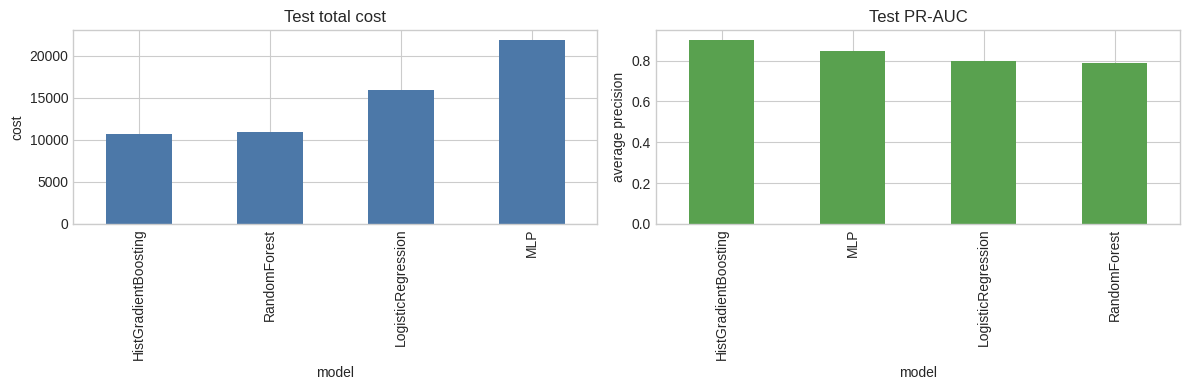

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
runs.sort_values('test_cost').plot(x='model', y='test_cost', kind='bar', ax=axes[0], legend=False, color='#4c78a8')
axes[0].set_title('Test total cost')
axes[0].set_ylabel('cost')
runs.sort_values('test_pr_auc', ascending=False).plot(x='model', y='test_pr_auc', kind='bar', ax=axes[1], legend=False, color='#59a14f')
axes[1].set_title('Test PR-AUC')
axes[1].set_ylabel('average precision')
plt.tight_layout()


## Порог и trade-off стоимости

Проверяем, что происходит при стандартном `0.5`, выбранном cost-sensitive пороге и порогах, которые дают целевые recall-уровни.


In [4]:
def threshold_for_recall(y_true, proba, target_recall):
    positives = np.sort(proba[y_true.to_numpy() == 1])
    if len(positives) == 0:
        return 0.5
    index = int(np.floor((1 - target_recall) * (len(positives) - 1)))
    return float(np.clip(positives[index], 0, 1))

thresholds_to_check = {
    'selected_cost_sensitive': threshold,
    'default_0_5': 0.5,
    'recall_95': threshold_for_recall(y_test, probability, 0.95),
    'recall_97': threshold_for_recall(y_test, probability, 0.97),
    'recall_99': threshold_for_recall(y_test, probability, 0.99),
}
threshold_reports = pd.DataFrame(
    {
        name: binary_report(
            y_test.to_numpy(), probability, value, false_positive_cost, false_negative_cost
        )
        for name, value in thresholds_to_check.items()
    }
).T
threshold_reports[['threshold', 'precision', 'recall', 'f1', 'average_precision', 'roc_auc', 'fp', 'fn', 'total_cost']]


,threshold,precision,recall,f1,average_precision,roc_auc,fp,fn,total_cost
selected_cost_sensitive,0.121241,0.372967,0.978667,0.540103,0.864343,0.994106,617.0,8.0,10170.0
default_0_5,0.500000,0.592217,0.933333,0.724638,0.864343,0.994106,241.0,25.0,14910.0
recall_95,0.287674,0.481132,0.952000,0.639212,0.864343,0.994106,385.0,18.0,12850.0
recall_97,0.186470,0.426230,0.970667,0.592352,0.864343,0.994106,490.0,11.0,10400.0
recall_99,0.048888,0.262712,0.992000,0.415410,0.864343,0.994106,1044.0,3.0,11940.0


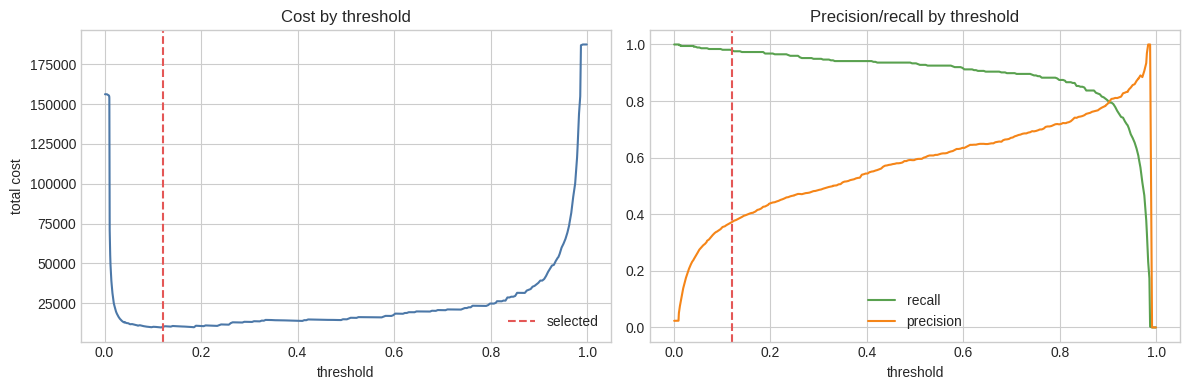

In [5]:
grid = np.unique(np.concatenate([np.linspace(0.001, 0.999, 250), np.quantile(probability, np.linspace(0, 1, 250))]))
curve = pd.DataFrame(
    [
        binary_report(y_test.to_numpy(), probability, float(t), false_positive_cost, false_negative_cost)
        for t in grid
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curve['threshold'], curve['total_cost'], color='#4c78a8')
axes[0].axvline(threshold, color='#e45756', linestyle='--', label='selected')
axes[0].set_title('Cost by threshold')
axes[0].set_xlabel('threshold')
axes[0].set_ylabel('total cost')
axes[0].legend()
axes[1].plot(curve['threshold'], curve['recall'], label='recall', color='#59a14f')
axes[1].plot(curve['threshold'], curve['precision'], label='precision', color='#f58518')
axes[1].axvline(threshold, color='#e45756', linestyle='--')
axes[1].set_title('Precision/recall by threshold')
axes[1].set_xlabel('threshold')
axes[1].legend()
plt.tight_layout()


## Матрица ошибок и группы кейсов

Разделяем test rows на TN/FP/FN/TP, чтобы смотреть не только агрегированные метрики, но и профиль ошибок.


In [6]:
error_frame = pd.DataFrame(
    {
        'y_true': y_test.to_numpy(),
        'probability': probability,
        'prediction': prediction,
        'missing_ratio': x_test.isna().mean(axis=1).to_numpy(),
        'zero_ratio': (x_test == 0).mean(axis=1).to_numpy(),
    },
    index=x_test.index,
)
error_frame['group'] = np.select(
    [
        (error_frame['y_true'] == 0) & (error_frame['prediction'] == 0),
        (error_frame['y_true'] == 0) & (error_frame['prediction'] == 1),
        (error_frame['y_true'] == 1) & (error_frame['prediction'] == 0),
        (error_frame['y_true'] == 1) & (error_frame['prediction'] == 1),
    ],
    ['TN', 'FP', 'FN', 'TP'],
    default='unknown',
)
error_frame['group'].value_counts().reindex(['TN', 'FP', 'FN', 'TP']).to_frame('rows')


,rows
group,
TN,15008
FP,617
FN,8
TP,367


In [7]:
error_frame.groupby('group').agg(
    rows=('group', 'size'),
    probability_mean=('probability', 'mean'),
    probability_median=('probability', 'median'),
    probability_p90=('probability', lambda s: s.quantile(0.90)),
    missing_ratio_mean=('missing_ratio', 'mean'),
    zero_ratio_mean=('zero_ratio', 'mean'),
).reindex(['TN', 'FP', 'FN', 'TP'])


,rows,probability_mean,probability_median,probability_p90,missing_ratio_mean,zero_ratio_mean
group,,,,,,
TN,15008,0.014715,0.010594,0.021565,0.077500,0.324363
FP,617,0.466716,0.386486,0.927154,0.186510,0.227924
FN,8,0.057920,0.052756,0.104426,0.089706,0.252206
TP,367,0.910973,0.973054,0.986738,0.180542,0.196394


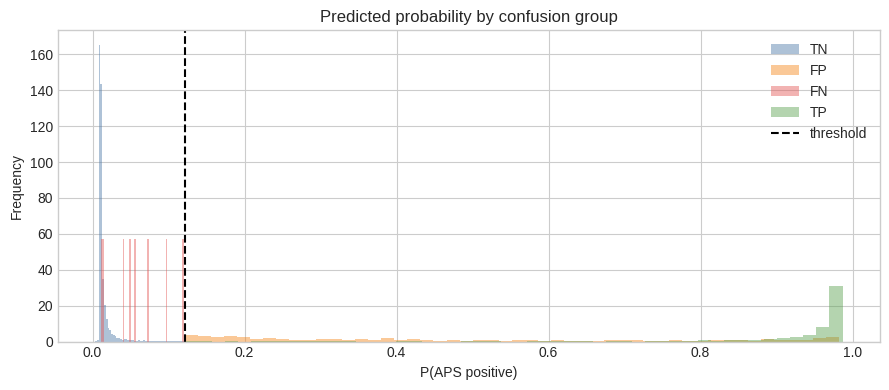

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for group, color in [('TN', '#4c78a8'), ('FP', '#f58518'), ('FN', '#e45756'), ('TP', '#59a14f')]:
    values = error_frame.loc[error_frame['group'] == group, 'probability']
    if len(values):
        values.plot(kind='hist', bins=50, alpha=0.45, density=True, ax=ax, label=group, color=color)
ax.axvline(threshold, color='black', linestyle='--', label='threshold')
ax.set_title('Predicted probability by confusion group')
ax.set_xlabel('P(APS positive)')
ax.legend()
plt.tight_layout()


## Чем отличаются FP/FN от корректных срабатываний

Сравниваем медианы по топ-признакам из permutation importance. Для APS особенно важны FN: это реальные APS-отказы, которые модель пропустила.


In [9]:
top_model_features = [item['feature'] for item in artifact.get('feature_importance', [])[:15]]
if not top_model_features:
    top_model_features = metrics['top_features'][:15]
    top_model_features = [item['feature'] for item in top_model_features]

group_medians = x_test.assign(group=error_frame['group']).groupby('group')[top_model_features].median().T
for column in ['TN', 'FP', 'FN', 'TP']:
    if column not in group_medians:
        group_medians[column] = np.nan
group_medians = group_medians[['TN', 'FP', 'FN', 'TP']]
group_medians['fp_minus_tn'] = group_medians['FP'] - group_medians['TN']
group_medians['fn_minus_tp'] = group_medians['FN'] - group_medians['TP']
group_medians


group,TN,FP,FN,TP,fp_minus_tn,fn_minus_tp
ck_000,224717.76,3830080.32,862045.92,7161474.24,3605362.56,-6299428.32
aa_000,29652.00,306582.00,63527.00,613530.00,276930.00,-550003.00
ay_006,163850.00,356543.00,172538.00,151954.00,192693.00,20584.00
bj_000,141747.00,2939484.00,702498.00,6408766.00,2797737.00,-5706268.00
ai_000,0.00,0.00,0.00,9710.00,0.00,-9710.00
az_002,938.00,18761.00,8586.00,53238.00,17823.00,-44652.00
ab_000,0.00,0.00,0.00,0.00,0.00,0.00
ac_000,152.00,524.00,264.00,920.00,372.00,-656.00
ad_000,124.00,572.00,224.00,802.00,448.00,-578.00
ae_000,0.00,0.00,0.00,0.00,0.00,0.00


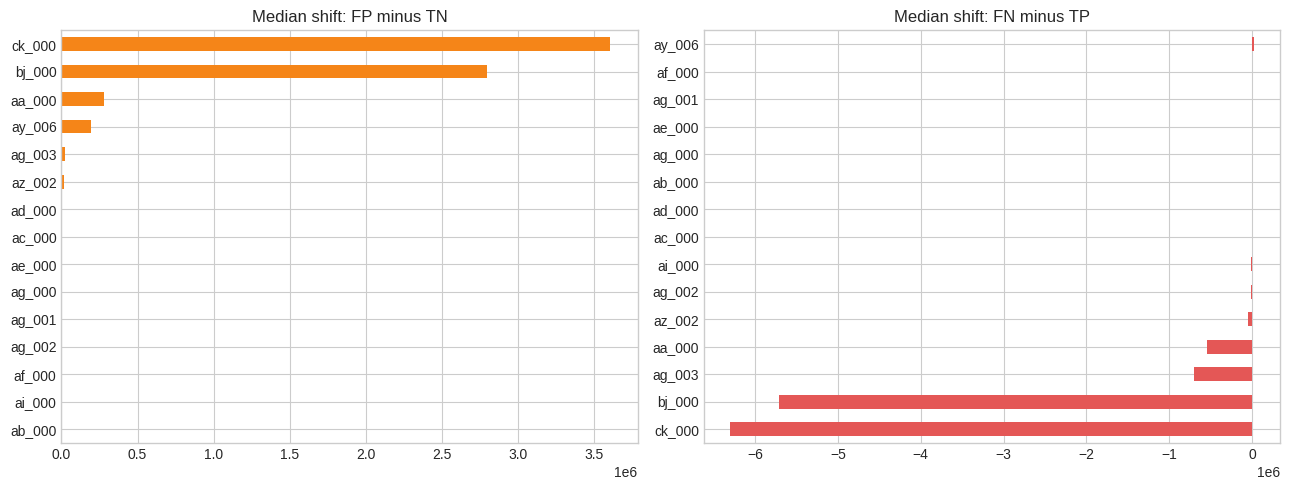

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
group_medians['fp_minus_tn'].sort_values().plot(kind='barh', ax=axes[0], color='#f58518')
axes[0].set_title('Median shift: FP minus TN')
group_medians['fn_minus_tp'].sort_values().plot(kind='barh', ax=axes[1], color='#e45756')
axes[1].set_title('Median shift: FN minus TP')
plt.tight_layout()


## Калибровочные бины

Смотрим, насколько средняя вероятность в бине похожа на фактическую долю positive. На редких событиях это особенно полезно для сервиса, где вероятность может показываться пользователю.


In [11]:
calibration = error_frame.copy()
calibration['probability_bin'] = pd.qcut(calibration['probability'].rank(method='first'), q=10, labels=False)
calibration_table = calibration.groupby('probability_bin').agg(
    rows=('y_true', 'size'),
    probability_min=('probability', 'min'),
    probability_mean=('probability', 'mean'),
    probability_max=('probability', 'max'),
    observed_positive_rate=('y_true', 'mean'),
    predicted_positive_rate=('prediction', 'mean'),
)
calibration_table


,rows,probability_min,probability_mean,probability_max,observed_positive_rate,predicted_positive_rate
probability_bin,,,,,,
0,1600,0.003298,0.009970,0.010201,0.000000,0.000
1,1600,0.010201,0.010230,0.010260,0.000000,0.000
2,1600,0.010260,0.010270,0.010281,0.000000,0.000
3,1600,0.010281,0.010322,0.010404,0.000000,0.000
4,1600,0.010404,0.010543,0.010612,0.000000,0.000
5,1600,0.010612,0.010935,0.011440,0.000625,0.000
6,1600,0.011442,0.012079,0.013119,0.000000,0.000
7,1600,0.013120,0.014857,0.017135,0.000625,0.000
8,1600,0.017146,0.023868,0.038667,0.000000,0.000


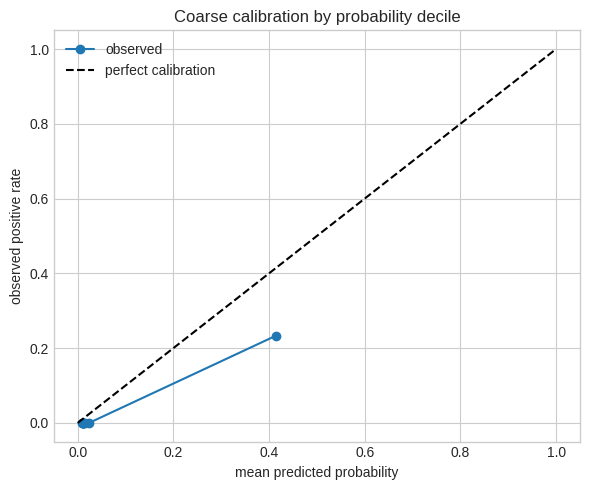

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(calibration_table['probability_mean'], calibration_table['observed_positive_rate'], marker='o', label='observed')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='perfect calibration')
ax.set_title('Coarse calibration by probability decile')
ax.set_xlabel('mean predicted probability')
ax.set_ylabel('observed positive rate')
ax.legend()
plt.tight_layout()


## Примеры ошибок для ручного разбора

Ниже — самые уверенные FP и FN с топ-признаками модели. Их удобно открыть при защите проекта: видно, где модель переоценивает или недооценивает APS-риск.


In [13]:
inspect_columns = ['probability', 'missing_ratio', 'zero_ratio'] + top_model_features[:10]
false_positive_cases = error_frame.query("group == 'FP'").sort_values('probability', ascending=False).head(10)
false_negative_cases = error_frame.query("group == 'FN'").sort_values('probability', ascending=True).head(10)

fp_view = false_positive_cases[['probability', 'missing_ratio', 'zero_ratio']].join(x_test.loc[false_positive_cases.index, top_model_features[:10]])
fn_view = false_negative_cases[['probability', 'missing_ratio', 'zero_ratio']].join(x_test.loc[false_negative_cases.index, top_model_features[:10]])
fp_view


,probability,missing_ratio,zero_ratio,ck_000,aa_000,ay_006,bj_000,ai_000,az_002,ab_000,ac_000,ad_000,ae_000
13971,0.982743,0.094118,0.241176,2061500.00,136652,0.0,3016294.0,0.0,2034.0,0.0,5054.0,NaN,0.0
11620,0.981801,0.352941,0.094118,5177365.44,1185108,24515942.0,10604630.0,31554.0,111676.0,NaN,NaN,NaN,NaN
5145,0.981572,0.105882,0.241176,38819138.88,675878,17927156.0,9140910.0,70370.0,31838.0,NaN,0.0,NaN,0.0
11560,0.980392,0.094118,0.241176,5134845.12,681064,0.0,3451486.0,1022.0,358.0,NaN,1594.0,NaN,0.0
7679,0.980266,0.352941,0.111765,8343157.44,1023736,51123808.0,13604140.0,3008650.0,99380.0,NaN,NaN,NaN,NaN
1429,0.980266,0.335294,0.105882,10472987.52,1078842,48499086.0,12339066.0,24892.0,150474.0,NaN,NaN,NaN,NaN
5105,0.980266,0.329412,0.111765,7362242.88,886486,34682068.0,10688150.0,96022.0,76494.0,NaN,NaN,NaN,NaN
4717,0.980266,0.329412,0.111765,11095807.68,1245620,51663834.0,10273886.0,49344.0,42154.0,NaN,NaN,NaN,NaN
4386,0.979556,0.352941,0.105882,5555798.40,718762,37458688.0,6167990.0,20348.0,61950.0,NaN,NaN,NaN,NaN
15880,0.978975,0.282353,0.494118,21183075.84,1276382,0.0,25310844.0,53930.0,0.0,NaN,NaN,NaN,0.0


In [14]:
fn_view


,probability,missing_ratio,zero_ratio,ck_000,aa_000,ay_006,bj_000,ai_000,az_002,ab_000,ac_000,ad_000,ae_000
3899,0.011297,0.047059,0.300000,65322.24,2532,0.0,42360.0,0.0,746.0,0.0,24.0,20.0,0.0
6603,0.014583,0.047059,0.247059,360782.40,44018,11570.0,262426.0,0.0,2594.0,NaN,510.0,210.0,0.0
15605,0.041646,0.117647,0.194118,903075.84,41574,277778.0,332520.0,2494.0,7370.0,NaN,524.0,NaN,0.0
9194,0.048888,0.270588,0.135294,8905681.92,482544,1785474.0,2971480.0,0.0,4012.0,0.0,NaN,NaN,NaN
6290,0.056624,0.035294,0.317647,538586.88,60672,0.0,634780.0,1762.0,9802.0,NaN,264.0,238.0,0.0
10237,0.072465,0.011765,0.235294,821016.00,66382,67298.0,770216.0,3210.0,22394.0,4.0,392.0,300.0,0.0
2222,0.097672,0.094118,0.294118,1782570.24,237120,5296936.0,778324.0,0.0,13778.0,NaN,0.0,NaN,0.0
902,0.120187,0.094118,0.294118,1572485.76,182646,2468878.0,1022656.0,0.0,11330.0,NaN,0.0,NaN,0.0
